<a href="https://colab.research.google.com/github/thadduslee/EGARCH-Sentiment-Analysis-GMMHMM-for-Volatility-Prediction-and-Portfolio-Optimisation/blob/main/NUS_Fintech_integrated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Portfolio Analysis Pipeline

**Full workflow:**
1. User inputs stocks and start date
2. Reddit scraping — posts/comments matching ticker keywords
3. Relevance filtering — zero-shot classifier keeps only genuinely relevant posts (≥ 0.7)
4. FinGPT sentiment analysis — runs on relevance-filtered posts only
5. Daily sentiment aggregation — averaged per-day signal fed into LSTM
6. Volatility prediction — EGARCH + GMM-HMM + LSTM per stock
7. Markowitz optimisation — forward-looking covariance matrix from predicted vols
8. Optimal weights — portfolio maximising Sharpe ratio
9. Monte Carlo simulation — 252-day wealth path simulation


## Step 0: Install Dependencies


In [1]:
!pip install -q arch hmmlearn praw yfinance tensorflow scikit-learn tqdm \
             transformers peft bitsandbytes accelerate huggingface_hub torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1: Imports


In [3]:
import os, sys, csv
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from hmmlearn.hmm import GMMHMM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import praw
from transformers import pipeline as hf_pipeline
from datetime import datetime, timezone, timedelta
from typing import List, Dict, Any, Tuple, Optional
from tqdm.auto import tqdm
import torch
import warnings
warnings.filterwarnings('ignore')
from google.colab import userdata

print('All imports OK.')


All imports OK.


## Step 2: User Input

Enter each stock ticker one at a time, then `Q` to finish.
Also enter the start date for all downstream analysis.


In [4]:
stocks = []
adding = True
while adding:
    temp = input('Enter a stock ticker (e.g. AAPL). Enter Q to finish: ').strip()
    if temp.upper() == 'Q':
        adding = False
    elif temp:
        stocks.append(temp.upper())

start = input('Enter start date for analysis (YYYY-MM-DD): ').strip()

print(f'Stocks selected : {stocks}')
print(f'Start date      : {start}')


Enter a stock ticker (e.g. AAPL). Enter Q to finish: AAPL
Enter a stock ticker (e.g. AAPL). Enter Q to finish: TSLA
Enter a stock ticker (e.g. AAPL). Enter Q to finish: Q
Enter start date for analysis (YYYY-MM-DD): 2023-01-01
Stocks selected : ['AAPL', 'TSLA']
Start date      : 2023-01-01


## Step 3: Reddit Scraping

Scrapes posts and comments from the configured subreddits filtered by ticker keywords
and start date. This is a **coarse keyword filter** — precise relevance is enforced
in Step 4 by the zero-shot classifier.

**Credentials:** set `REDDIT_CLIENT_ID`, `REDDIT_CLIENT_SECRET`, and optionally
`REDDIT_USER_AGENT` as Colab Secrets (🔑 sidebar). Make sure *Notebook access* is **ON**.


In [5]:
# ── CONFIG ───────────────────────────────────────────────────────────────────
SUBREDDITS = [
    'wallstreetbets', 'stocks', 'StockMarket',
    'CryptoCurrency', 'finance', 'fintech',
]
MAX_POST_TEXT_CHARS    = 5000
MAX_COMMENT_TEXT_CHARS = 3000
OUT_POSTS_CSV          = 'reddit_posts.csv'
OUT_COMMENTS_CSV       = 'reddit_comments.csv'
OUT_POST_CONCAT_CSV    = 'reddit_postid_comments_concat.csv'
OUT_FILTERED_CSV       = 'reddit_filtered_relevant.csv'
OUT_SENTIMENT_CSV      = 'reddit_sentiment_results.csv'

SGT = timezone(timedelta(hours=8))

# ── AUTH ─────────────────────────────────────────────────────────────────────
REDDIT_CLIENT_ID     = userdata.get('REDDIT_CLIENT_ID')
REDDIT_CLIENT_SECRET = userdata.get('REDDIT_CLIENT_SECRET')
REDDIT_USER_AGENT    = userdata.get('REDDIT_USER_AGENT') or 'reddit-scraper-script'

if not REDDIT_CLIENT_ID or not REDDIT_CLIENT_SECRET:
    raise ValueError('Missing Reddit credentials. Set them as Colab Secrets.')

reddit = praw.Reddit(
    client_id=REDDIT_CLIENT_ID,
    client_secret=REDDIT_CLIENT_SECRET,
    user_agent=REDDIT_USER_AGENT,
)

# ── TICKER ALIASES ────────────────────────────────────────────────────────────
# Coarse keyword expansion used for the initial scrape pass.
# The zero-shot classifier in Step 4 handles precision filtering.
TICKER_ALIASES: Dict[str, List[str]] = {
    'TSLA'   : ['tsla', 'tesla'],
    'AAPL'   : ['aapl', 'apple'],
    'GOOG'   : ['goog', 'googl', 'google'],
    'GOOGL'  : ['goog', 'googl', 'google'],
    'PLTR'   : ['pltr', 'palantir'],
    'MSFT'   : ['msft', 'microsoft'],
    'AMZN'   : ['amzn', 'amazon'],
    'NVDA'   : ['nvda', 'nvidia'],
    'META'   : ['meta', 'facebook'],
    'BTC-USD': ['btc', 'bitcoin'],
    'ETH-USD': ['eth', 'ethereum'],
    'WMT'    : ['wmt', 'walmart'],
    'JPM'    : ['jpm', 'jpmorgan'],
    'BAC'    : ['bac', 'bank of america'],
    'DIS'    : ['dis', 'disney'],
    'NFLX'   : ['nflx', 'netflix'],
    'AMD'    : ['amd'],
    'INTC'   : ['intc', 'intel'],
    'UBER'   : ['uber'],
    'LYFT'   : ['lyft'],
}

# ── HELPERS ───────────────────────────────────────────────────────────────────
def clamp_text(text: Optional[str], max_chars: int) -> str:
    text = (text or '').strip()
    return text if len(text) <= max_chars else text[:max_chars] + ' ...[truncated]'

def extract_post_id(link_id: Optional[str]) -> Optional[str]:
    if not link_id: return None
    s = str(link_id)
    return s[3:] if s.startswith('t3_') else s

def parse_start_date_to_utc_ts(s: str) -> float:
    return datetime.fromisoformat(s).replace(tzinfo=timezone.utc).timestamp()

def keyword_match(text: str, keywords: List[str]) -> bool:
    """Intentionally broad — false positives are removed by the relevance filter."""
    if not keywords: return True
    t = (text or '').lower()
    return any(k in t for k in keywords)

def write_csv(path: str, rows: List[Dict[str, Any]]) -> None:
    if not rows:
        print(f'Warning: No rows for {path}'); return
    fieldnames = sorted({k for r in rows for k in r.keys()})
    with open(path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction='ignore')
        writer.writeheader(); writer.writerows(rows)

print('Scraper config and helpers loaded.')


Scraper config and helpers loaded.


In [6]:
def scrape_since_with_keywords(
    start_ts: float, keywords: List[str],
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    posts, comments = [], []
    seen_posts, seen_comments = set(), set()

    for sub in SUBREDDITS:
        sr = reddit.subreddit(sub)
        print(f'Posts: r/{sub}')
        for p in sr.new(limit=None):
            if p.id in seen_posts: continue
            if p.created_utc < start_ts: break
            full_text = f'{p.title} {p.selftext or ""}'
            if not keyword_match(full_text, keywords): continue
            posts.append({
                'post_id'              : p.id,
                'subreddit'            : str(p.subreddit),
                'author'               : str(p.author) if p.author else None,
                'created_utc'          : p.created_utc,
                'created_sgt'          : datetime.fromtimestamp(p.created_utc, tz=SGT).isoformat(),
                'title'                : p.title,
                'selftext'             : clamp_text(p.selftext, MAX_POST_TEXT_CHARS),
                'combined_text'        : clamp_text(full_text, MAX_POST_TEXT_CHARS),
                'score'                : int(p.score),
                'upvote_ratio'         : getattr(p, 'upvote_ratio', None),
                'num_comments'         : int(p.num_comments),
                'total_awards_received': int(getattr(p, 'total_awards_received', 0) or 0),
                'permalink'            : f'https://reddit.com{p.permalink}',
                'url'                  : getattr(p, 'url', None),
                'over_18'              : bool(getattr(p, 'over_18', False)),
                'stickied'             : bool(getattr(p, 'stickied', False)),
                'locked'               : bool(getattr(p, 'locked', False)),
            })
            seen_posts.add(p.id)

        print(f'Comments: r/{sub}')
        for c in sr.comments(limit=None):
            if c.id in seen_comments: continue
            if c.created_utc < start_ts: break
            body = getattr(c, 'body', '') or ''
            if not keyword_match(body, keywords): continue
            comments.append({
                'comment_id'           : c.id,
                'post_id'              : extract_post_id(getattr(c, 'link_id', None)),
                'parent_id'            : getattr(c, 'parent_id', None),
                'subreddit'            : str(c.subreddit),
                'author'               : str(c.author) if c.author else None,
                'created_utc'          : c.created_utc,
                'created_sgt'          : datetime.fromtimestamp(c.created_utc, tz=SGT).isoformat(),
                'body'                 : clamp_text(body, MAX_COMMENT_TEXT_CHARS),
                'score'                : int(getattr(c, 'score', 0) or 0),
                'total_awards_received': int(getattr(c, 'total_awards_received', 0) or 0),
                'is_submitter'         : bool(getattr(c, 'is_submitter', False)),
                'distinguished'        : getattr(c, 'distinguished', None),
                'permalink'            : f'https://reddit.com{c.permalink}',
            })
            seen_comments.add(c.id)
    return posts, comments


def build_post_concat(
    posts: List[Dict[str, Any]], comments: List[Dict[str, Any]]
) -> List[Dict[str, Any]]:
    comments_by_post: Dict[str, List] = {}
    for c in comments:
        pid = c.get('post_id')
        if pid: comments_by_post.setdefault(pid, []).append(c)

    rows = []
    for p in posts:
        pid = p['post_id']
        post_comments = comments_by_post.get(pid, [])
        if not post_comments:
            try:
                sub = reddit.submission(id=pid)
                sub.comments.replace_more(limit=0)
                post_comments = [
                    {'body': c.body, 'created_utc': c.created_utc}
                    for c in sub.comments.list()
                    if (c.body or '').strip() not in ('', '[deleted]', '[removed]')
                ]
            except Exception as e:
                print(f'Could not fetch comments for {pid}: {e}')
        post_comments = sorted(post_comments, key=lambda x: x.get('created_utc') or 0)
        concat = ' ||| '.join(
            c.get('body', '').strip() for c in post_comments if (c.get('body') or '').strip()
        )
        rows.append({
            'post_id'            : pid,
            'post_text'          : p.get('combined_text', ''),
            'all_comments_concat': concat if concat else None,
        })
    return rows

print('Scraper functions loaded.')


Scraper functions loaded.


In [7]:
expanded: set = set()
for s in stocks:
    expanded.update(TICKER_ALIASES.get(s, [s.lower()]))
keywords = list(expanded)
print(f'Scraping Reddit for keywords: {keywords}')

start_ts = parse_start_date_to_utc_ts(start)
posts, comments = scrape_since_with_keywords(start_ts, keywords)

write_csv(OUT_POSTS_CSV, posts)
write_csv(OUT_COMMENTS_CSV, comments)

post_concat_rows = build_post_concat(posts, comments)
write_csv(OUT_POST_CONCAT_CSV, post_concat_rows)

print(f'\nScraping done.')
print(f'  Posts       : {len(posts)}')
print(f'  Comments    : {len(comments)}')
print(f'  Concat rows : {len(post_concat_rows)}')


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.



Scraping Reddit for keywords: ['aapl', 'apple', 'tsla', 'tesla']
Posts: r/wallstreetbets


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

Comments: r/wallstreetbets


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

...

Posts: r/fintech


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

Comments: r/fintech


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l


Scraping done.
  Posts       : 137
  Comments    : 12
  Concat rows : 137


## Step 4: Relevance Filtering (Zero-Shot Classification)

Uses `facebook/bart-large-mnli` to score every scraped post against each requested ticker.
A post is kept if it scores **≥ 0.7** for **at least one** ticker.

This removes false positives that passed the keyword filter:
- *'I ate an apple for lunch'* → dropped when filtering `AAPL`
- *'this discussion is very meta'* → dropped when filtering `META`

The output DataFrame `df_relevant` is the **only** data passed to FinGPT — keeping
inference cost and noise low.


In [8]:
# BART-large-mnli is ~1.6 GB. It is deleted after filtering so FinGPT has full VRAM.
relevance_device = 0 if torch.cuda.is_available() else -1
print(f'Loading zero-shot classifier on device={relevance_device}...')
zero_shot = hf_pipeline(
    task='zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=relevance_device,
)
print('Classifier loaded.')

# The model understands natural language — 'Apple stock' scores far better than 'AAPL'.
TICKER_TO_COMPANY: Dict[str, str] = {
    'TSLA'   : 'Tesla',     'AAPL'   : 'Apple',    'GOOG'   : 'Google',
    'GOOGL'  : 'Google',    'PLTR'   : 'Palantir', 'MSFT'   : 'Microsoft',
    'AMZN'   : 'Amazon',    'NVDA'   : 'Nvidia',   'META'   : 'Meta',
    'BTC-USD': 'Bitcoin',   'ETH-USD': 'Ethereum', 'WMT'    : 'Walmart',
    'JPM'    : 'JPMorgan',  'BAC'    : 'Bank of America',
    'DIS'    : 'Disney',    'NFLX'   : 'Netflix',  'AMD'    : 'AMD',
    'INTC'   : 'Intel',     'UBER'   : 'Uber',     'LYFT'   : 'Lyft',
}

RELEVANCE_THRESHOLD  = 0.7
RELEVANCE_MAX_CHARS  = 1024
RELEVANCE_BATCH_SIZE = 16


def score_relevance_batch(texts: List[str], stock: str) -> List[float]:
    """Returns per-text relevance confidence scores for `stock`."""
    company = TICKER_TO_COMPANY.get(stock.upper(), stock)
    # Two competing labels force the softmax to discriminate rather than output ~1.0 always.
    candidate_labels = [
        f'This text is about {company} stock or its business',
        f'This text is not about {company}',
    ]
    relevant_label = candidate_labels[0]
    truncated = [(t or '').strip()[:RELEVANCE_MAX_CHARS] for t in texts]
    scores = []
    for i in range(0, len(truncated), RELEVANCE_BATCH_SIZE):
        batch = truncated[i : i + RELEVANCE_BATCH_SIZE]
        for res in zero_shot(batch, candidate_labels):
            scores.append(dict(zip(res['labels'], res['scores']))[relevant_label])
    return scores


def filter_by_relevance(
    df: pd.DataFrame,
    stocks: List[str],
    text_col: str = 'combined_text',
    threshold: float = RELEVANCE_THRESHOLD,
) -> pd.DataFrame:
    """
    Scores every row per ticker and keeps rows relevant to at least one ticker.
    Adds: relevance_{TICKER}, matched_tickers, max_relevance_score.
    """
    texts = df[text_col].astype(str).tolist()
    df = df.copy()
    for stock in stocks:
        print(f'  Scoring relevance for {stock}...')
        col = f'relevance_{stock.replace("-", "_")}'
        df[col] = score_relevance_batch(texts, stock)

    rel_cols = [f'relevance_{s.replace("-", "_")}' for s in stocks]
    df['max_relevance_score'] = df[rel_cols].max(axis=1)
    df['matched_tickers'] = df.apply(
        lambda row: ', '.join(s for s, col in zip(stocks, rel_cols) if row[col] >= threshold),
        axis=1,
    )
    # FIX: original code returned `filter` (the builtin) instead of `filtered`
    filtered = df[df['max_relevance_score'] >= threshold].reset_index(drop=True)
    return filtered

print('Relevance filter functions loaded.')


Loading zero-shot classifier on device=0...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Classifier loaded.
Relevance filter functions loaded.


In [9]:
df_reddit = pd.read_csv(OUT_POST_CONCAT_CSV)

# Build combined_text: post body + all comments concatenated
# This single field is scored for relevance AND fed into FinGPT
df_reddit['combined_text'] = df_reddit.apply(
    lambda row: (
        str(row['post_text']) + ' ||| ' + str(row['all_comments_concat'])
        if pd.notna(row['all_comments_concat'])
           and str(row['all_comments_concat']).strip() != ''
        else str(row['post_text'])
    ),
    axis=1,
)

print(f'Loaded {len(df_reddit)} posts. Running relevance filter (threshold={RELEVANCE_THRESHOLD})...')

df_relevant = filter_by_relevance(
    df=df_reddit, stocks=stocks, text_col='combined_text', threshold=RELEVANCE_THRESHOLD,
)

df_relevant.to_csv(OUT_FILTERED_CSV, index=False)

dropped = len(df_reddit) - len(df_relevant)
print(f'\nRelevance filtering complete.')
print(f'  Before  : {len(df_reddit)} posts')
print(f'  After   : {len(df_relevant)} posts  ({dropped} dropped)')
print(f'  Saved   : {OUT_FILTERED_CSV}')

display(df_relevant[['post_id','matched_tickers','max_relevance_score','post_text']]
        .sort_values('max_relevance_score', ascending=False).head(10))


Loaded 137 posts. Running relevance filter (threshold=0.7)...
  Scoring relevance for AAPL...
  Scoring relevance for TSLA...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Relevance filtering complete.
  Before  : 137 posts
  After   : 57 posts  (80 dropped)
  Saved   : reddit_filtered_relevant.csv


,post_id,matched_tickers,max_relevance_score,post_text
33,1qmmh1g,"AAPL, TSLA",0.985709,"This Week in Markets: Jan 26-30, 2026 Source: ..."
21,1rrtk75,TSLA,0.976164,Tesla swings continue as EV leadership changes...
32,1qnt5eg,AAPL,0.975651,JP Morgan boosts Apple price target ahead of q...
30,1qprsha,AAPL,0.975213,What I am looking for in Apple's earnings. Pri...
43,1pzib20,TSLA,0.968331,Tesla Q4 deliveries estimated down 15% YoY as ...
28,1qqlrv5,AAPL,0.967816,Apple tops Q1 earnings
46,1pomnq6,TSLA,0.967204,Tesla vs reality This is outrageous how is Tes...
1,1rrqci3,TSLA,0.965709,If you'd invest 10k in wallstreetbets stock pi...
49,1pnl08s,TSLA,0.959030,Tesla +3.6% after Musk confirms driverless rob...
51,1oqdlxc,TSLA,0.952781,Tesla Shareholders Approve Elon Musk’s $1 Tril...


In [10]:
# Free BART (~1.6 GB) before loading FinGPT (~8 GB) to avoid VRAM OOM.
del zero_shot
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('Zero-shot classifier freed. VRAM ready for FinGPT.')


Zero-shot classifier freed. VRAM ready for FinGPT.


## Step 5: Sentiment Analysis (FinGPT)

Loads FinGPT (LLaMA 3 8B + LoRA adapters) and runs batched sentiment inference
on the **relevance-filtered** posts only. Results are aggregated into a
**daily sentiment signal** that feeds into the LSTM as extra features.

**Prerequisites:**
- Upload `utils.py` to `/content/utils.py` in Colab
- Set `HF_TOKEN` as a Colab Secret (LLaMA 3 is a gated HuggingFace model)
- Mount Google Drive so the LoRA weights path is accessible


In [11]:
from google.colab import drive
drive.mount('/content/drive')

sys.path.insert(0, '/content')

from huggingface_hub import login
login(token=userdata.get('HF_TOKEN'))

from utils import load_fingpt, sentiment_probs_batch, LABELS

peft_model = '/content/drive/MyDrive/extracted_lora/outputs/lora_int8_sentiment'
tokenizer, fingpt_model = load_fingpt(peft_model, 'cuda')

print(f'FinGPT loaded. Running on {len(df_relevant)} relevance-filtered posts.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/177 [00:00<?, ?B/s]

FinGPT loaded. Running on 57 relevance-filtered posts.


In [12]:
device = str(next(fingpt_model.parameters()).device)
print(f'Model device: {device}')

# df_relevant already has combined_text built during the relevance step
texts = df_relevant['combined_text'].astype(str).tolist()

batch_size = 2  # increase to 16-32 if VRAM > 16 GB
preds, prob_rows = [], []

for s in tqdm(range(0, len(texts), batch_size), desc='Sentiment inference'):
    batch = texts[s : s + batch_size]
    _, probs = sentiment_probs_batch(
        tokenizer, fingpt_model,
        input_sentences=batch, labels=LABELS,
        max_length=1024, device=device,
    )
    probs_cpu = probs.detach().cpu()
    preds.extend([LABELS[i] for i in probs_cpu.argmax(dim=1).tolist()])
    prob_rows.extend(probs_cpu.tolist())

df_relevant = df_relevant.copy()
df_relevant['pred_sentiment'] = preds
df_relevant['p_negative']     = [p[0] for p in prob_rows]
df_relevant['p_neutral']      = [p[1] for p in prob_rows]
df_relevant['p_positive']     = [p[2] for p in prob_rows]

df_relevant.to_csv(OUT_SENTIMENT_CSV, index=False)
print(f'Saved {OUT_SENTIMENT_CSV}')

display(df_relevant[[
    'post_id', 'matched_tickers', 'max_relevance_score',
    'pred_sentiment', 'p_negative', 'p_neutral', 'p_positive',
]].head(10))


Model device: cuda:0


Sentiment inference:   0%|          | 0/29 [00:00<?, ?it/s]

Saved reddit_sentiment_results.csv


,post_id,matched_tickers,max_relevance_score,pred_sentiment,p_negative,p_neutral,p_positive
0,1rsyo1n,AAPL,0.898440,negative,0.493447,0.071088,0.435465
1,1rrqci3,TSLA,0.965709,negative,0.750192,0.214514,0.035293
2,1rmt4uq,TSLA,0.945785,negative,0.633011,0.206313,0.160677
3,1r9w4ex,TSLA,0.858971,negative,0.696793,0.225334,0.077873
4,1r6io1o,AAPL,0.896699,negative,0.558866,0.193139,0.247995
5,1r2wg5h,TSLA,0.872845,negative,0.560858,0.075608,0.363534
6,1r20bn4,TSLA,0.871438,negative,0.537244,0.325855,0.136902
7,1r0i9on,TSLA,0.757680,negative,0.580592,0.273183,0.146224
8,1qxv1qc,TSLA,0.923973,negative,0.697851,0.060978,0.241171
9,1rtm570,TSLA,0.920573,negative,0.528343,0.250548,0.221108


In [13]:
# Free FinGPT before TensorFlow LSTM training — both compete for the same GPU.
del fingpt_model, tokenizer
torch.cuda.empty_cache()
print('FinGPT freed from GPU. VRAM available for LSTM training.')


FinGPT freed from GPU. VRAM available for LSTM training.


## Step 6: Daily Sentiment Aggregation

Averages per-post sentiment scores into a daily signal.
This `daily_sentiment` DataFrame is joined into the LSTM feature matrix per stock.
Posts from `df_relevant` are used — already relevance-filtered, so the signal is clean.


In [15]:
# Use the posts CSV for timestamps; sentiment scores come from OUT_SENTIMENT_CSV.
# We use df_relevant directly (already in memory) and merge timestamps from posts CSV.
posts_df = pd.read_csv(OUT_POSTS_CSV)
sent_df  = pd.read_csv(OUT_SENTIMENT_CSV)

merged = sent_df.merge(posts_df[['post_id', 'created_sgt']], on='post_id', how='left')
merged['date'] = pd.to_datetime(merged['created_sgt']).dt.normalize()
merged['date'] = merged['date'].dt.tz_localize(None)

daily_sentiment = (
    merged.groupby('date')[['p_positive', 'p_negative', 'p_neutral']]
    .mean()
)
daily_sentiment.index = pd.to_datetime(daily_sentiment.index)

#print(f'Daily sentiment computed for {len(daily_sentiment)} trading days.')
#print(daily_sentiment.head())


## Step 7: Volatility Prediction (EGARCH + GMM-HMM + LSTM)

For each stock:
- **GMM-HMM** identifies 3 market regimes (Low / Medium / High volatility)
- **EGARCH** extracts conditional volatility as a feature
- **LSTM** combines all features — including daily Reddit sentiment — to forecast
  next-day annualised volatility


In [16]:
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)


In [17]:
def hidden_markov_model_gmm(ticker, start):
    """Fit GMM-HMM on log-returns. Returns (regime_series, prob_dists, transition_matrix)."""
    data = yf.download(ticker, start=start, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        data = data.xs(ticker, level=1, axis=1) if ticker in data.columns.levels[1] else data

    data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1))
    data.dropna(inplace=True)
    X = data['Log_Returns'].values.reshape(-1, 1)

    model = GMMHMM(n_components=3, n_mix=2, covariance_type='diag',
                   n_iter=1000, random_state=42)
    model.fit(X)

    variances = []
    for i in range(model.n_components):
        weighted_var = np.dot(model.weights_[i], model.covars_[i])
        variances.append(weighted_var[0])
    variances = np.array(variances)

    sorted_order = np.argsort(variances)
    reorder_map  = {old: new for new, old in enumerate(sorted_order)}
    hidden_states = model.predict(X)
    data['Regime'] = np.array([reorder_map[s] for s in hidden_states])

    regime_names = ['Low', 'Medium', 'High']
    probability_distributions = {'Mean': {}, 'Standard Deviation': {}}
    print(f'--- Regime Parameters for {ticker} (GMM-HMM) ---')
    for i in range(model.n_components):
        oi = sorted_order[i]
        w_mean = np.dot(model.weights_[oi], model.means_[oi])[0]
        w_std  = np.sqrt(np.dot(model.weights_[oi], model.covars_[oi])[0])
        probability_distributions['Mean'][regime_names[i]] = w_mean
        probability_distributions['Standard Deviation'][regime_names[i]] = w_std
        print(f'  Regime {i} ({regime_names[i]}): mean={w_mean:.5f}, vol={w_std:.5f}')

    plt.figure(figsize=(14, 8))
    colors = ['green', 'gold', 'red']
    plt.plot(data.index, data['Close'], color='black', alpha=0.1)
    for i, color in enumerate(colors):
        mask = data['Regime'] == i
        plt.scatter(data.index[mask], data['Close'][mask], s=10, c=color,
                    label=f'{regime_names[i]} Volatility', alpha=0.6, edgecolors='none')
    plt.title(f'GMM-HMM Regime Detection for {ticker}', fontsize=16)
    plt.ylabel('Price ($)', fontsize=12)
    plt.legend(); plt.grid(True, alpha=0.3); plt.show()

    transition_matrix = model.transmat_[sorted_order, :][:, sorted_order]
    print('\nTransition Matrix (State i -> j):')
    print(transition_matrix)
    return data['Regime'], probability_distributions, transition_matrix


In [18]:
def predict_next_day_volatility_annualised(ticker, start):
    """EGARCH + GMM-HMM + LSTM volatility forecast with Reddit sentiment features."""

    # ── 1. Download price data ────────────────────────────────────────────────
    data = yf.download(ticker, start=start)
    if isinstance(data.columns, pd.MultiIndex):
        data = data.xs(ticker, level=1, axis=1, drop_level=True)

    # ── 2. GMM-HMM regimes ───────────────────────────────────────────────────
    data['regime'], probability_distribution, transition_matrix = \
        hidden_markov_model_gmm(ticker, start)

    # ── 3. Feature engineering ───────────────────────────────────────────────
    data['log_returns'] = np.log(data['Close'] / data['Close'].shift(1)) * 100

    indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=5)
    data['target_volatility']      = data['log_returns'].rolling(window=indexer).std().shift(-1)
    data['target_vol_log']         = np.log(data['target_volatility'])
    data['volatility_lag_week']    = data['log_returns'].rolling(5).std().shift(1)
    data['volatility_lag_month']   = data['log_returns'].rolling(22).std().shift(1)
    data['volatility_lag_quarter'] = data['log_returns'].rolling(66).std().shift(1)
    data['absolute_returns_lag']   = abs(data['log_returns'].shift(1))
    log_hl = np.log(data['High'] / data['Low'])
    log_co = np.log(data['Close'] / data['Open'])
    data['garman_klass'] = np.sqrt(
        np.maximum(0, 0.5 * log_hl**2 - (2*np.log(2)-1) * log_co**2)
    ) * 100
    data['vol_change'] = data['Volume'].pct_change()

    # ── 4. Merge daily Reddit sentiment ──────────────────────────────────────
    # daily_sentiment is built from relevance-filtered, sentiment-scored posts only
    data.index = pd.to_datetime(data.index).tz_localize(None)
    data = data.join(daily_sentiment, how='left')
    data[['p_positive', 'p_negative', 'p_neutral']] = (
        data[['p_positive', 'p_negative', 'p_neutral']]
        .ffill()
        .fillna(0.333)  # neutral prior on days with no Reddit signal
    )

    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    data.dropna(inplace=True)

    # ── 5. Train / test split ────────────────────────────────────────────────
    split    = int(len(data) * 0.8)
    training = data.iloc[:split].copy()
    testing  = data.iloc[split:].copy()

    # ── 6. EGARCH on ORIGINAL (unscaled) log returns ─────────────────────────
    train_mean   = training['log_returns'].mean()
    egarch_train = arch_model(training['log_returns'] - train_mean,
                              vol='EGARCH', p=1, q=1, dist='t')
    egarch_fit   = egarch_train.fit(disp='off')
    training['garch_volatility'] = egarch_fit.conditional_volatility

    egarch_test  = arch_model(testing['log_returns'] - train_mean,
                              vol='EGARCH', p=1, q=1, dist='t')
    testing['garch_volatility'] = egarch_test.fix(egarch_fit.params).conditional_volatility

    # ── 7. EGARCH 1-step forecast (on original data, before scaling) ─────────
    full_data_orig = pd.concat([training, testing])
    next_garch_vol = (
        arch_model(full_data_orig['log_returns'] - train_mean,
                   vol='EGARCH', p=1, q=1, dist='t')
        .fix(egarch_fit.params)
        .forecast(horizon=1).variance.iloc[-1].values[0] ** 0.5
    )

    time_steps    = 10
    features = [
        'log_returns', 'volatility_lag_week', 'volatility_lag_month',
        'volatility_lag_quarter', 'garch_volatility', 'absolute_returns_lag',
        'vol_change', 'garman_klass', 'p_positive', 'p_negative', 'p_neutral',
    ]
    last_seq_orig = full_data_orig[features].iloc[-time_steps:].copy()
    last_seq_orig.iloc[-1, last_seq_orig.columns.get_loc('garch_volatility')] = next_garch_vol

    # ── 8. Scale features ────────────────────────────────────────────────────
    scaler = StandardScaler()
    training[features] = scaler.fit_transform(training[features])
    testing[features]  = scaler.transform(testing[features])

    X_train, y_train    = create_sequences(training[features], training['target_vol_log'])
    X_test,  y_test_log = create_sequences(testing[features],  testing['target_vol_log'])

    val_split   = int(len(X_train) * 0.9)
    X_tr, X_val = X_train[:val_split], X_train[val_split:]
    y_tr, y_val = y_train[:val_split], y_train[val_split:]

    # ── 9. Build and train LSTM ──────────────────────────────────────────────
    lstm_model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(X_tr.shape[1], X_tr.shape[2])),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1),
    ])
    lstm_model.compile(optimizer='adam', loss='mse')
    lstm_model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=20, batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1,
    )

    # ── 10. Forecast next-day volatility ─────────────────────────────────────
    last_seq_scaled   = scaler.transform(last_seq_orig)
    last_seq_reshaped = last_seq_scaled.reshape(1, time_steps, len(features))

    pred_log_vol   = lstm_model.predict(last_seq_reshaped, verbose=0)[0][0]
    pred_daily_vol = np.exp(pred_log_vol)
    annualised_vol = pred_daily_vol * np.sqrt(252)

    # Record current regime (last row of full data)
    current_regime = full_data_orig['regime'].iloc[-1]

    print(f'  Predicted annualised vol : {annualised_vol:.4f}%')
    print(f'  Current regime           : {current_regime}')

    return annualised_vol, transition_matrix, probability_distribution, current_regime



========== AAPL ==========


[*********************100%***********************]  1 of 1 completed


--- Regime Parameters for AAPL (GMM-HMM) ---
  Regime 0 (Low): mean=0.00094, vol=0.01392
  Regime 1 (Medium): mean=-0.01423, vol=0.01486
  Regime 2 (High): mean=0.01189, vol=0.06310


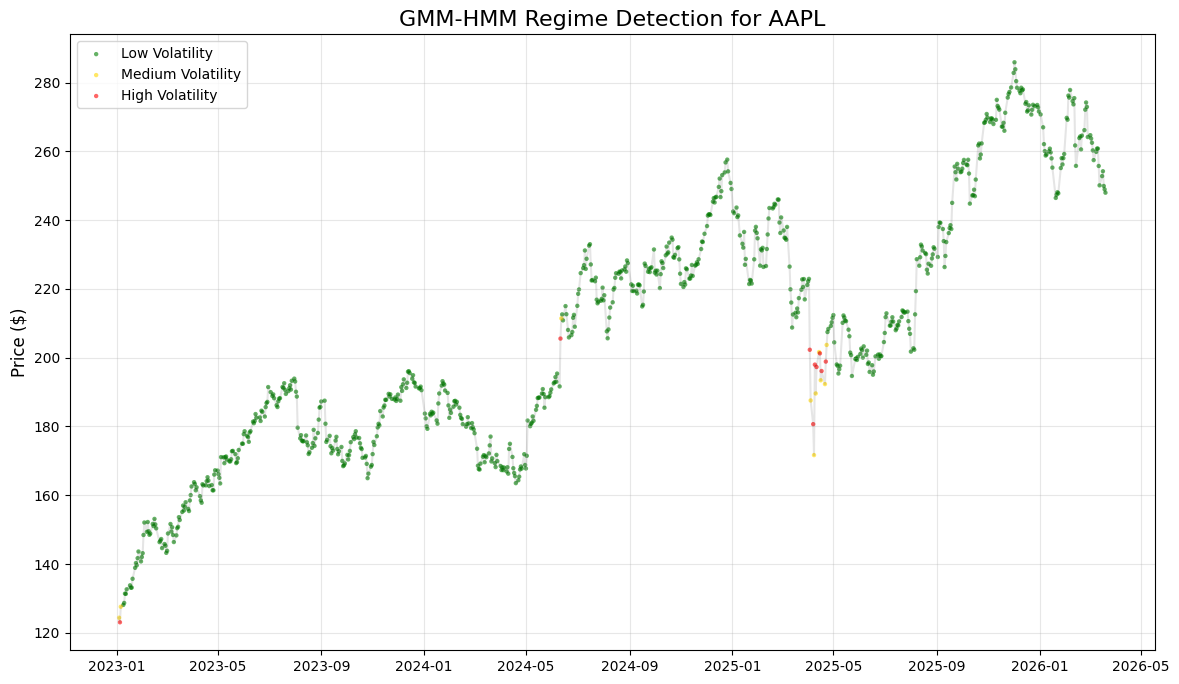


Transition Matrix (State i -> j):
[[9.96384046e-01 1.44456439e-06 3.61450967e-03]
 [3.74301768e-01 2.06859827e-11 6.25698232e-01]
 [2.15967510e-06 9.99997840e-01 4.49681143e-15]]
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - loss: 0.3125 - val_loss: 0.3271
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2639 - val_loss: 0.3336
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2531 - val_loss: 0.4539
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2393 - val_loss: 0.5156
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2271 - val_loss: 0.6517
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2242 - val_loss: 0.7238


[*********************100%***********************]  1 of 1 completed

  Predicted annualised vol : 29.4004%
  Current regime           : 0.0

========== TSLA ==========


--- Regime Parameters for TSLA (GMM-HMM) ---
  Regime 0 (Low): mean=-0.00065, vol=0.02834
  Regime 1 (Medium): mean=0.02404, vol=0.03338
  Regime 2 (High): mean=-0.00190, vol=0.03362


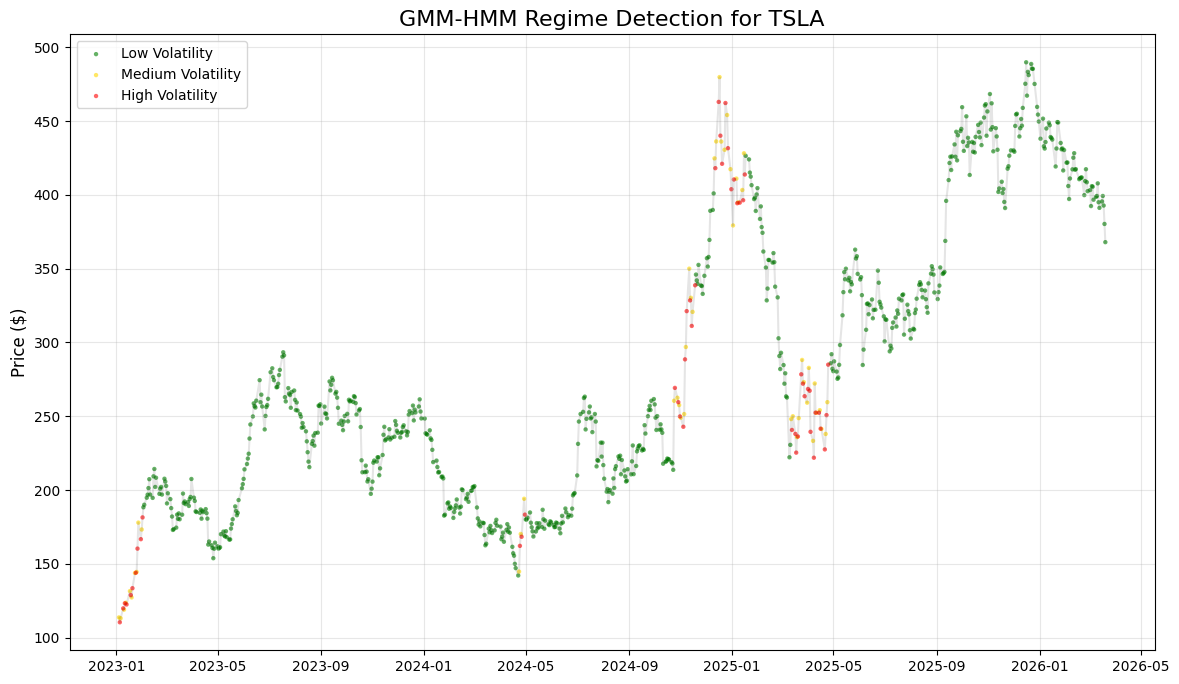


Transition Matrix (State i -> j):
[[9.84437694e-01 1.54382228e-02 1.24082957e-04]
 [4.82888469e-05 5.97387506e-04 9.99354324e-01]
 [1.39152823e-01 8.01459418e-01 5.93877584e-02]]
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.9960 - val_loss: 1.8705
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3491 - val_loss: 1.3509
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2911 - val_loss: 1.4822
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2701 - val_loss: 1.5082
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2636 - val_loss: 1.4727
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2634 - val_loss: 1.3921
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2599 - val_loss: 1.4454
  Predicted annualised vol : 24.9573%
  Current regime           : 0.0

--- Volatility Summary ---
  AAPL: 29.4004% annualised vol | current regime: 0.0
  TSLA: 24.9573% annualised vol | current regime: 0.0


In [19]:
predicted_annual_volatilities = {}
transition_matrices           = {}
probability_distributions     = {}
current_regimes               = {}

for stock in stocks:
    print(f'\n========== {stock} ==========')
    ann_vol, trans_mat, prob_dist, cur_regime = \
        predict_next_day_volatility_annualised(stock, start)
    predicted_annual_volatilities[stock] = ann_vol
    transition_matrices[stock]           = trans_mat
    probability_distributions[stock]     = prob_dist
    current_regimes[stock]               = cur_regime

print('\n--- Volatility Summary ---')
for s, v in predicted_annual_volatilities.items():
    print(f'  {s}: {v:.4f}% annualised vol | current regime: {current_regimes[s]}')


## Step 8: Markowitz Portfolio Optimisation

Uses **LSTM-predicted forward-looking volatility** to build the covariance matrix,
then simulates 10,000 random portfolios to trace out the Efficient Frontier.


[*********************100%***********************]  2 of 2 completed



--- Forward-Looking Covariance Matrix (Annualised) ---
          AAPL      TSLA
AAPL  0.086438  0.027225
TSLA  0.027225  0.062286


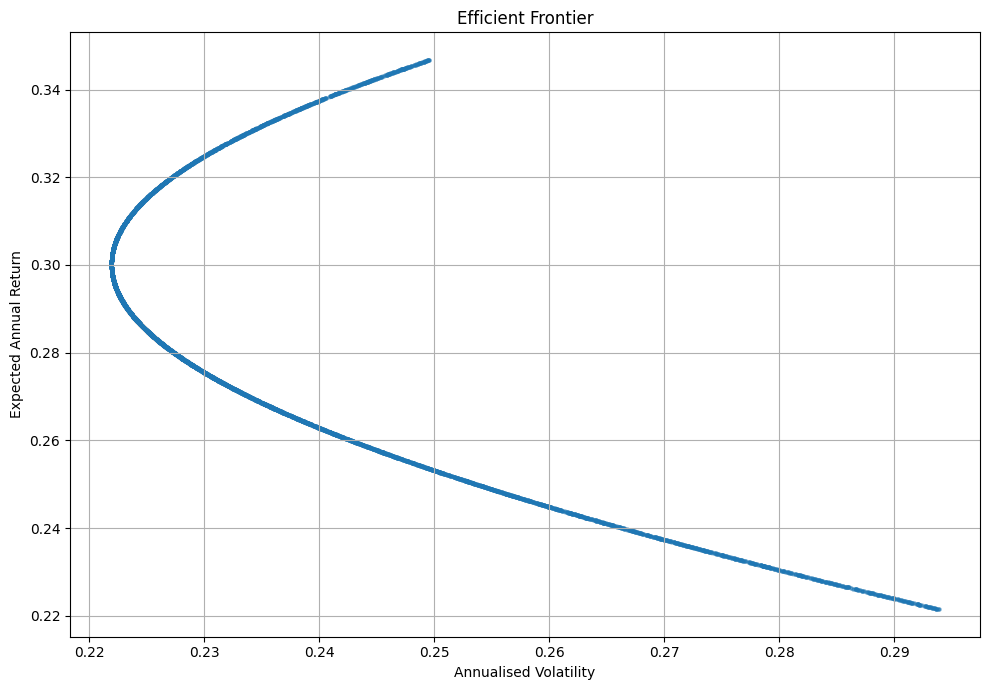

In [20]:
# Full price history for historical correlation
price_data   = yf.download(stocks, start='1900-01-01')['Close']
returns_data = np.log(price_data / price_data.shift(1))
returns_data.dropna(inplace=True)

if isinstance(returns_data, pd.Series):
    returns_data = returns_data.to_frame(name=stocks[0])

correlation_matrix = returns_data.corr()

# Forward-looking covariance matrix: LSTM-predicted vols + historical correlations
D = np.diag([predicted_annual_volatilities[s] / 100 for s in stocks])
future_variance_matrix = D @ correlation_matrix.values @ D

print('\n--- Forward-Looking Covariance Matrix (Annualised) ---')
print(pd.DataFrame(future_variance_matrix, index=stocks, columns=stocks).round(6))

num_stocks, num_portfolios = len(stocks), 10000
risk_free_rate      = 0.04
mean_annual_returns = (returns_data.mean() * 252)[stocks]

ret_list, vol_list, alloc_list = [], [], []
for _ in range(num_portfolios):
    w = np.random.random(num_stocks); w /= w.sum()
    alloc_list.append(w)
    ret_list.append(np.dot(w, mean_annual_returns))
    vol_list.append(np.sqrt(w.T @ future_variance_matrix @ w))

data_pf = {'Returns': ret_list, 'Volatilities': vol_list}
for i, sym in enumerate(stocks):
    data_pf[sym + ' Weight'] = [a[i] for a in alloc_list]
portfolio = pd.DataFrame(data_pf)

portfolio.plot.scatter(x='Volatilities', y='Returns', figsize=(10, 7),
                       alpha=0.3, s=5, grid=True, title='Efficient Frontier')
plt.xlabel('Annualised Volatility'); plt.ylabel('Expected Annual Return')
plt.tight_layout(); plt.show()


## Step 9: Optimal Portfolio Weights (Max Sharpe Ratio)


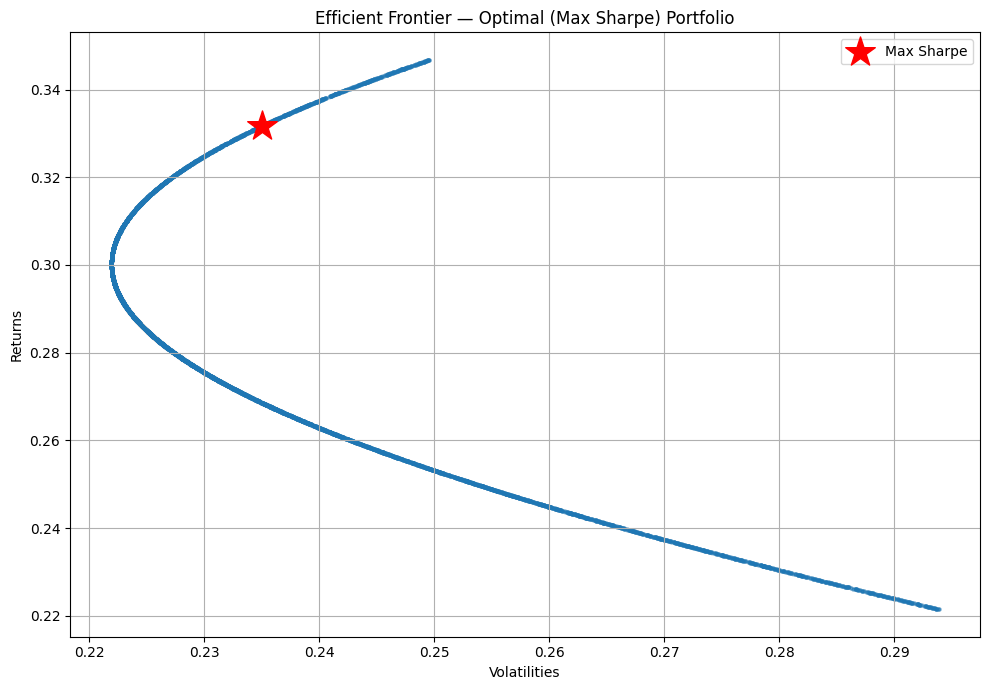

Expected Annual Return : 33.17%
Annualised Volatility  : 23.50%
Sharpe Ratio           : 1.2414

Optimal Portfolio Weights:
  AAPL: 12.03%
  TSLA: 87.97%


In [21]:
sharpe_idx = ((portfolio['Returns'] - risk_free_rate) / portfolio['Volatilities']).idxmax()
optimal_pf = portfolio.iloc[sharpe_idx]

portfolio.plot.scatter(x='Volatilities', y='Returns', figsize=(10, 7),
                       alpha=0.3, s=5, grid=True,
                       title='Efficient Frontier — Optimal (Max Sharpe) Portfolio')
plt.scatter(optimal_pf['Volatilities'], optimal_pf['Returns'],
            color='red', marker='*', s=500, zorder=5, label='Max Sharpe')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Expected Annual Return : {optimal_pf["Returns"]*100:.2f}%')
print(f'Annualised Volatility  : {optimal_pf["Volatilities"]*100:.2f}%')
print(f'Sharpe Ratio           : {(optimal_pf["Returns"]-risk_free_rate)/optimal_pf["Volatilities"]:.4f}')

weights = optimal_pf.iloc[2:].to_numpy()
weights_with_stock_name = dict(zip(stocks, weights))
print('\nOptimal Portfolio Weights:')
for sym, w in weights_with_stock_name.items():
    print(f'  {sym}: {w*100:.2f}%')


## Step 10: Monte Carlo Simulation

Simulates 252 trading days of portfolio wealth paths. Each stock's daily return is
sampled from its GMM regime distribution, and regimes transition daily via the
Markov transition matrix.


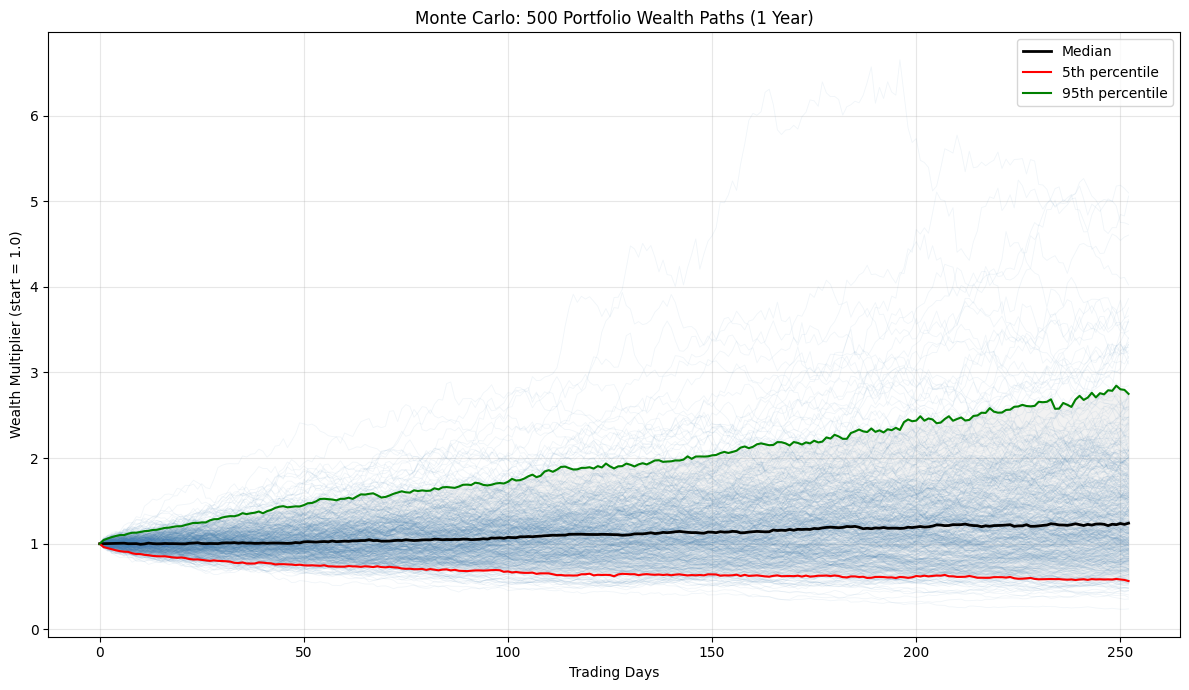

--- After 1 Year (500 simulations) ---
  Median final wealth : 1.2403x
  5th percentile      : 0.5642x
  95th percentile     : 2.7502x
  Probability of loss : 31.6%


In [22]:
FLOAT_TO_STR  = {0.0: 'Low', 1.0: 'Medium', 2.0: 'High'}
REGIME_STATES = [0.0, 1.0, 2.0]


def get_portfolio_return(cur_regimes):
    daily_return = 0.0
    for stock, weight in weights_with_stock_name.items():
        r    = FLOAT_TO_STR[float(cur_regimes[stock])]
        mean = probability_distributions[stock]['Mean'][r]
        std  = probability_distributions[stock]['Standard Deviation'][r]
        daily_return += weight * np.random.normal(mean, std)
    return daily_return


def update_regimes(cur_regimes):
    return {
        stock: np.random.choice(
            REGIME_STATES,
            p=transition_matrices[stock][int(cur_regimes[stock])]
        )
        for stock in weights_with_stock_name
    }


def simulate_portfolio_year(start_wealth, init_regimes):
    wealth, path = start_wealth, [start_wealth]
    cur = dict(init_regimes)
    for _ in range(252):
        wealth *= (1 + get_portfolio_return(cur))
        path.append(wealth)
        cur = update_regimes(cur)
    return path


def monte_carlo(num_paths=500):
    all_paths = np.array([
        simulate_portfolio_year(1.0, current_regimes) for _ in range(num_paths)
    ])

    p5,  p50, p95 = (
        np.percentile(all_paths, 5,  axis=0),
        np.percentile(all_paths, 50, axis=0),
        np.percentile(all_paths, 95, axis=0),
    )
    all_final = all_paths[:, -1]

    plt.figure(figsize=(12, 7))
    for path in all_paths:
        plt.plot(path, color='steelblue', alpha=0.08, linewidth=0.6)
    x = range(253)
    plt.plot(x, p50, color='black',  linewidth=2,   label='Median')
    plt.plot(x, p5,  color='red',    linewidth=1.5, label='5th percentile')
    plt.plot(x, p95, color='green',  linewidth=1.5, label='95th percentile')
    plt.fill_between(x, p5, p95, alpha=0.1, color='grey')
    plt.title(f'Monte Carlo: {num_paths} Portfolio Wealth Paths (1 Year)')
    plt.xlabel('Trading Days'); plt.ylabel('Wealth Multiplier (start = 1.0)')
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    print(f'--- After 1 Year ({num_paths} simulations) ---')
    print(f'  Median final wealth : {np.median(all_final):.4f}x')
    print(f'  5th percentile      : {np.percentile(all_final,  5):.4f}x')
    print(f'  95th percentile     : {np.percentile(all_final, 95):.4f}x')
    print(f'  Probability of loss : {(all_final < 1.0).mean()*100:.1f}%')


monte_carlo(num_paths=500)
